# XGB Fraud with Magic scores LB 0.96
This model is part of the 1st place solution to Kaggle's "IEEE-CIS Fraud Detection" competition. When this model is ensembled together with [Konstantin's][1] CatBoost and LGBM models, the result achieves public LB 0.9677 and private LB 0.9459 taking first place [here][2]
  
In this kernel, we build two XGB models. The first model does not use the magic features and achieves LB 0.95. The second model uses the magic features and achieves LB 0.96. In the appendix, we demonstrate how to increase LB further with post processing.

Reading one million rows of data from disk and engineering features takes 5 minutes using Pandas and CPU. Alternatively if we use RAPIDS cuDF and GPU, it takes only 20 seconds! CPU times are displayed beneath code blocks below and GPU 15x speed up is demonstrated [here][3]. 

[1]: https://www.kaggle.com/kyakovlev
[2]: https://www.kaggle.com/c/ieee-fraud-detection/leaderboard
[3]: https://www.kaggle.com/cdeotte/rapids-feature-engineering-fraud-0-96/

# How the Magic Works
The magic is two things. First we need a UID variable to identify clients (credit cards). Second, we need to create aggregated group features. Then we remove UID. Suppose we had 10 transactions `A, B, C, D, E, F, G, H, I, J` as below.  
  
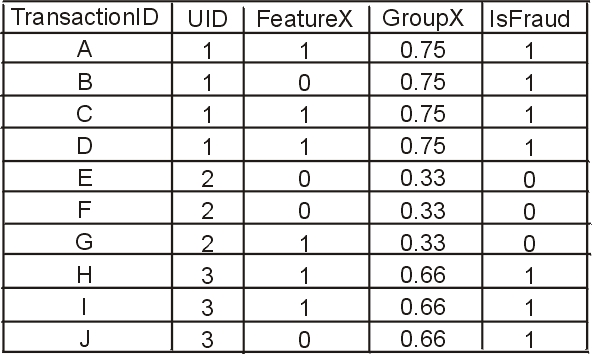
  
If we only use FeatureX, we can classify 70% of the transactions correctly. Below, yellow circles are `isFraud=1` and blue circles are `isFraud=0` transactions. After the tree model below splits data into left child and right child, we predict `isFraud=1` for left child and `isFraud=0` for right child. Thus 7 out of 10 predictions are correct.
  
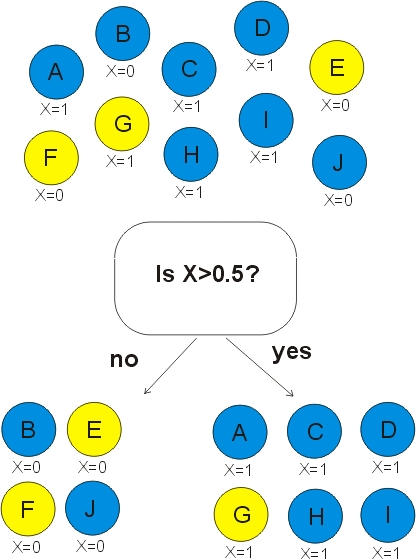  
  
Now suppose that we have a UID which defines groups and we make an aggregated feature by taking the average of FeatureX within each group. We can now classify 100% of the transactions correctly. Note that we never use the feature UID in our decision tree.  
  
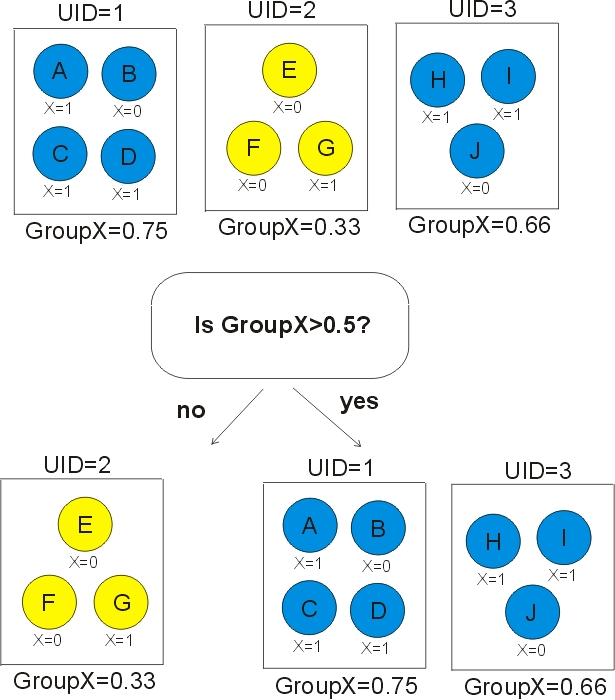

# Load Data
We will load all the data except 219 V columns that were determined redundant by correlation analysis [here][1]

[1]: https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id

In [1]:
%pip install numpy pandas scikit-learn matplotlib seaborn tensorflow keras-tcn spektral scipy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
BUILD95 = True
BUILD96 = True

import numpy as np, pandas as pd, os, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# COLUMNS WITH STRINGS
str_type = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
str_type += ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']

# FIRST 53 COLUMNS
cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

In [3]:
%%time
# LOAD TRAIN
X_train = pd.read_csv('/kaggle/input/datasets/jenishsorathiya/ies-challenge/data/train_transaction.csv',index_col='TransactionID', dtype=dtypes, usecols=cols+['isFraud'])
train_id = pd.read_csv('/kaggle/input/datasets/jenishsorathiya/ies-challenge/data/train_identity.csv',index_col='TransactionID', dtype=dtypes)
X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)
# LOAD TEST
X_test = pd.read_csv('/kaggle/input/datasets/jenishsorathiya/ies-challenge/data/test_transaction.csv',index_col='TransactionID', dtype=dtypes, usecols=cols)
test_id = pd.read_csv('/kaggle/input/datasets/jenishsorathiya/ies-challenge/data/test_identity.csv',index_col='TransactionID', dtype=dtypes)
fix = {o:n for o, n in zip(test_id.columns, train_id.columns)}
test_id.rename(columns=fix, inplace=True)
X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)
# TARGET
y_train = X_train['isFraud'].copy()
del train_id, test_id, X_train['isFraud']; x = gc.collect()
# PRINT STATUS
print('Train shape',X_train.shape,'test shape',X_test.shape)

Train shape (590540, 213) test shape (506691, 213)
CPU times: user 22.7 s, sys: 1.78 s, total: 24.5 s
Wall time: 26.7 s


# Normalize D Columns
The D Columns are "time deltas" from some point in the past. We will transform the D Columns into their point in the past. This will stop the D columns from increasing with time. The formula is `D15n = Transaction_Day - D15` and `Transaction_Day = TransactionDT/(24*60*60)`. Afterward we multiple this number by negative one.

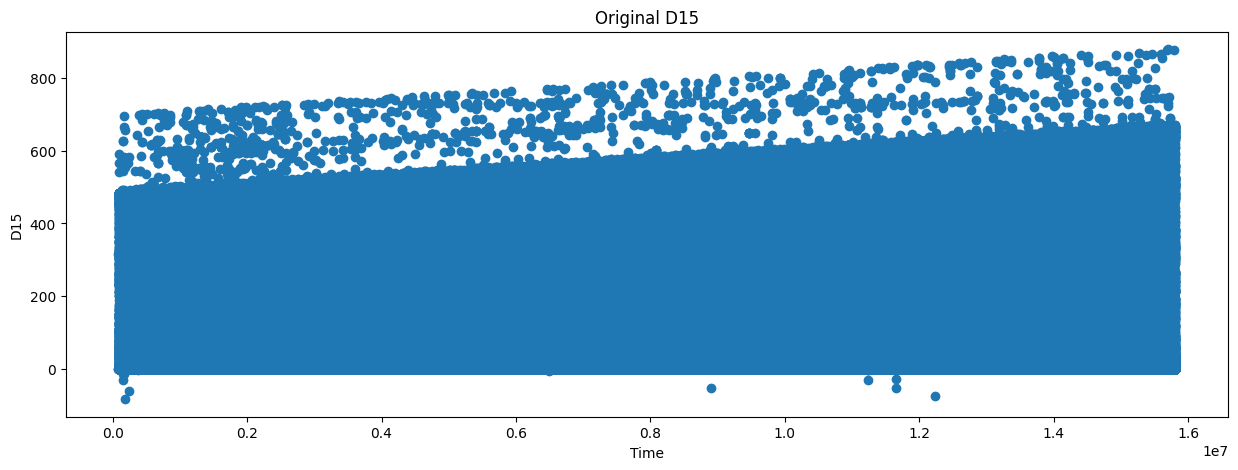

In [4]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [5]:
# NORMALIZE D COLUMNS
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
    X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60) 

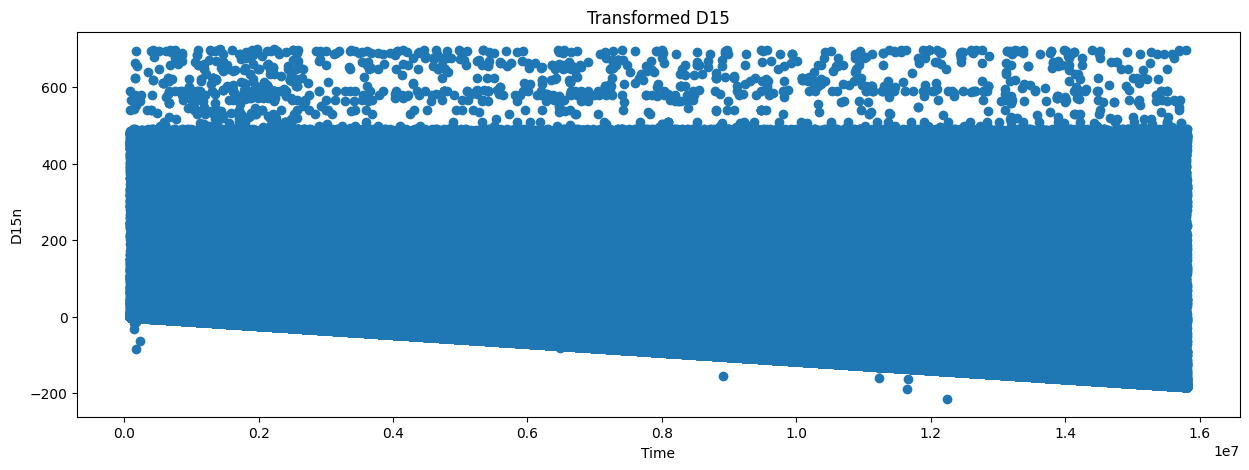

In [6]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

In [7]:
%%time
# LABEL ENCODE AND MEMORY REDUCE
for i,f in enumerate(X_train.columns):
    # FACTORIZE CATEGORICAL VARIABLES
    if (str(X_train[f].dtype)=='category')|(X_train[f].dtype=='object'): 
        df_comb = pd.concat([X_train[f],X_test[f]],axis=0)
        df_comb,_ = df_comb.factorize(sort=True)
        if df_comb.max()>32000: print(f,'needs int32')
        X_train[f] = df_comb[:len(X_train)].astype('int16')
        X_test[f] = df_comb[len(X_train):].astype('int16')
    # SHIFT ALL NUMERICS POSITIVE. SET NAN to -1
    elif f not in ['TransactionAmt','TransactionDT']:
        mn = np.min((X_train[f].min(),X_test[f].min()))
        X_train[f] -= np.float32(mn)
        X_test[f] -= np.float32(mn)
        X_train[f].fillna(-1,inplace=True)
        X_test[f].fillna(-1,inplace=True)

<timed exec>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<timed exec>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, t

CPU times: user 2.32 s, sys: 365 ms, total: 2.68 s
Wall time: 2.68 s


# Encoding Functions
Below are 5 encoding functions. (1) `encode_FE` does frequency encoding where it combines train and test first and then encodes. (2) `encode_LE` is a label encoded for categorical features (3) `encode_AG` makes aggregated features such as aggregated mean and std (4) `encode_CB` combines two columns (5) `encode_AG2` makes aggregated features where it counts how many unique values of one feature is within a group. For more explanation about feature engineering, see the discussion [here][1]

[1]: https://www.kaggle.com/c/ieee-fraud-detection/discussion/108575#latest-641841

In [8]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# Feature Engineering
We will now engineer features. All of these features where chosen because each increases local validation. The procedure for engineering features is as follows. First you think of an idea and create a new feature. Then you add it to your model and evaluate whether local validation AUC increases or decreases. If AUC increases keep the feature, otherwise discard the feature.

In [9]:
%%time
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , 

<timed exec>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/tmp/ipykernel_55/2377275247.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1[nm] = df1[col].map(vc)
/tmp/ipykernel_55/2377275247.py:10: PerformanceWarning: DataFrame is high

card3_FE , P_emaildomain_FE , 

/tmp/ipykernel_55/2377275247.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
/tmp/ipykernel_55/2377275247.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str)


card1_addr1 , 

...

/tmp/ipykernel_55/2377275247.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will 

'D11_card1_addr1_std' , 

/tmp/ipykernel_55/2377275247.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will 

'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , CPU times: user 5.83 s, sys: 525 ms, total: 6.36 s
Wall time: 6.3 s


/tmp/ipykernel_55/2377275247.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will 

# Feature Selection - Time Consistency
We added 28 new feature above. We have already removed 219 V Columns from correlation analysis done [here][1]. So we currently have 242 features now. We will now check each of our 242 for "time consistency". We will build 242 models. Each model will be trained on the first month of the training data and will only use one feature. We will then predict the last month of the training data. We want both training AUC and validation AUC to be above `AUC = 0.5`. It turns out that 19 features fail this test so we will remove them. Additionally we will remove 7 D columns that are mostly NAN. More techniques for feature selection are listed [here][2]

[1]: https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
[2]: https://www.kaggle.com/c/ieee-fraud-detection/discussion/111308

In [10]:
import datetime
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_train['DT_M'] = (X_train['DT_M'].dt.year-2017)*12 + X_train['DT_M'].dt.month 

X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_test['DT_M'] = (X_test['DT_M'].dt.year-2017)*12 + X_test['DT_M'].dt.month 

/tmp/ipykernel_55/3600872321.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
/tmp/ipykernel_55/3600872321.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))


In [11]:
X_train['day'] = X_train.TransactionDT / (24*60*60)
X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)

X_test['day'] = X_test.TransactionDT / (24*60*60)
X_test['uid'] = X_test.card1_addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

/tmp/ipykernel_55/1456880997.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['day'] = X_train.TransactionDT / (24*60*60)
/tmp/ipykernel_55/1456880997.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)
/tmp/ipykernel_55/1456880997.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usi

In [12]:
%%time
# FREQUENCY ENCODE UID
encode_FE(X_train,X_test,['uid'])
# AGGREGATE 
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
# AGGREGATE
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
# AGGREGATE
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREGATE
encode_AG(['C14'],['uid'],['std'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE 
encode_AG2(['C13','V314'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREATE 
encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train, test_df=X_test)
# NEW FEATURE
X_train['outsider15'] = (np.abs(X_train.D1-X_train.D15)>3).astype('int8')
X_test['outsider15'] = (np.abs(X_test.D1-X_test.D15)>3).astype('int8')
print('outsider15')

/tmp/ipykernel_55/2377275247.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1[nm] = df1[col].map(vc)
/tmp/ipykernel_55/2377275247.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2[nm] = df2[col].map(vc)


uid_FE , 

/tmp/ipykernel_55/2377275247.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will 

'TransactionAmt_uid_mean' , 

/tmp/ipykernel_55/2377275247.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
/tmp/ipykernel_55/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will 

...

/tmp/ipykernel_55/2377275247.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
/tmp/ipykernel_55/2377275247.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')


uid_V307_ct, 

/tmp/ipykernel_55/2377275247.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')


uid_V320_ct, outsider15
CPU times: user 1min 26s, sys: 1.84 s, total: 1min 28s
Wall time: 1min 28s


/tmp/ipykernel_55/2377275247.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
<timed exec>:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [13]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['DT_M','day','uid']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [14]:
# cols = list( X_train.columns )
# cols.remove('TransactionDT')
# for c in ['D6','D7','D8','D9','D12','D13','D14']:
#     cols.remove(c)
    
# # FAILED TIME CONSISTENCY TEST
# for c in ['C3','M5','id_08','id_33']:
#     cols.remove(c)
# for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
#     cols.remove(c)
# for c in ['id_'+str(x) for x in range(22,28)]:
#     cols.remove(c)

In [15]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 263 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

In [16]:
import sys
import tensorflow as tf

print(sys.version)
print("TF:", tf.__version__)


2026-04-10 21:07:02.818020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775855223.026119      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775855223.088317      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775855223.582068      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775855223.582091      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775855223.582094      55 computation_placer.cc:177] computation placer alr

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TF: 2.19.0


In [17]:

%%time
# Import TCN-specific libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tcn import TCN  # keras-tcn package

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score, confusion_matrix, roc_curve
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("✓ TCN libraries imported successfully!")

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✓ TCN libraries imported successfully!
CPU times: user 40.8 ms, sys: 342 ms, total: 383 ms
Wall time: 1.12 s


In [18]:
# TCN Hyperparameters
SEQUENCE_LENGTH = 20  # Reshape 220 features into 10 timesteps × 22 features
TCN_FILTERS = 128
KERNEL_SIZE = 3
DILATIONS = [1, 2, 4, 8]  # Receptive field = 31
DROPOUT_RATE = 0.2
DENSE_UNITS = [128, 64, 32]

# Training Parameters
BATCH_SIZE = 512
EPOCHS = 200
LEARNING_RATE = 0.0005
VALIDATION_SPLIT = 0.2
PATIENCE_ES = 50
PATIENCE_LR = 10

# Paths
MODEL_SAVE_PATH = "/kaggle/working/models"
RESULTS_PATH = "/kaggle/working/results"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("=" * 50)
print("TCN CONFIGURATION")
print("=" * 50)
print(f"Features: {len(cols)}")
print(f"Sequence Length: {SEQUENCE_LENGTH}")
print(f"TCN Filters: {TCN_FILTERS}")
print(f"Dilations: {DILATIONS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("=" * 50)

TCN CONFIGURATION
Features: 263
Sequence Length: 20
TCN Filters: 128
Dilations: [1, 2, 4, 8]
Batch Size: 512
Epochs: 200


In [19]:
%%time
print("=" * 50)
print("PREPARING DATA FOR TCN")
print("=" * 50)

# Get features and target
X_tcn = X_train[cols].copy()
y_tcn = y_train.copy()

# Convert to numpy arrays
X_tcn = X_tcn.values
y_tcn = y_tcn.values

print(f"\nOriginal shape: {X_tcn.shape}")
print(f"Target shape: {y_tcn.shape}")
print(f"Features: {len(cols)}")

# Check for any remaining issues
print(f"\nNaN count: {np.isnan(X_tcn).sum()}")
print(f"Inf count: {np.isinf(X_tcn).sum()}")

# Train-Validation Split (stratified to maintain fraud ratio)
X_train_tcn, X_val_tcn, y_train_tcn, y_val_tcn = train_test_split(
    X_tcn, y_tcn,
    test_size=VALIDATION_SPLIT,
    random_state=42,
    stratify=y_tcn
)

print(f"\nTrain samples: {X_train_tcn.shape[0]:,}")
print(f"Validation samples: {X_val_tcn.shape[0]:,}")
print(f"Fraud % in train: {(y_train_tcn.sum() / len(y_train_tcn) * 100):.2f}%")
print(f"Fraud % in val: {(y_val_tcn.sum() / len(y_val_tcn) * 100):.2f}%")

# CRITICAL: Apply StandardScaler (neural networks need this!)
print("\n" + "=" * 50)
print("APPLYING STANDARDSCALER")
print("=" * 50)
scaler = StandardScaler()
X_train_tcn = scaler.fit_transform(X_train_tcn)
X_val_tcn = scaler.transform(X_val_tcn)

print(f"Mean after scaling: {X_train_tcn.mean():.6f}")
print(f"Std after scaling: {X_train_tcn.std():.6f}")

# Calculate class weights for imbalanced data
class_counts = np.bincount(y_train_tcn.astype(int))
class_weights = {
    0: len(y_train_tcn) / (2 * class_counts[0]),
    1: len(y_train_tcn) / (2 * class_counts[1])
}
print(f"\nClass Weights:")
print(f"  Legitimate (0): {class_weights[0]:.4f}")
print(f"  Fraud (1): {class_weights[1]:.4f}")

print("\n✓ Data preprocessing completed!")
print("=" * 50)

PREPARING DATA FOR TCN

Original shape: (590540, 263)
Target shape: (590540,)
Features: 263

NaN count: 0
Inf count: 0

Train samples: 472,432
Validation samples: 118,108
Fraud % in train: 3.50%
Fraud % in val: 3.50%

APPLYING STANDARDSCALER
Mean after scaling: -0.000000
Std after scaling: 1.000000

Class Weights:
  Legitimate (0): 0.5181
  Fraud (1): 14.2901

✓ Data preprocessing completed!
CPU times: user 4.99 s, sys: 1.87 s, total: 6.86 s
Wall time: 6.86 s


In [20]:
print("=" * 50)
print("RESHAPING FOR TCN")
print("=" * 50)

n_features = X_train_tcn.shape[1]
features_per_timestep = n_features // SEQUENCE_LENGTH
remainder = n_features % SEQUENCE_LENGTH

print(f"\nFeatures: {n_features}")
print(f"Sequence Length: {SEQUENCE_LENGTH}")
print(f"Features per timestep: {features_per_timestep}")
print(f"Remainder: {remainder}")

# Pad if necessary
if remainder != 0:
    pad_width = SEQUENCE_LENGTH - remainder
    print(f"\nPadding {pad_width} features with zeros...")
    X_train_tcn = np.pad(X_train_tcn, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
    X_val_tcn = np.pad(X_val_tcn, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
    features_per_timestep = X_train_tcn.shape[1] // SEQUENCE_LENGTH

# Reshape to 3D: (samples, sequence_length, features_per_timestep)
X_train_tcn = X_train_tcn.reshape(-1, SEQUENCE_LENGTH, features_per_timestep)
X_val_tcn = X_val_tcn.reshape(-1, SEQUENCE_LENGTH, features_per_timestep)

print(f"\nReshaped to 3D:")
print(f"  Train: {X_train_tcn.shape}")
print(f"  Validation: {X_val_tcn.shape}")
print(f"\nFormat: (samples, {SEQUENCE_LENGTH} timesteps, {features_per_timestep} features)")
print("\n✓ Data ready for TCN!")
print("=" * 50)

RESHAPING FOR TCN

Features: 263
Sequence Length: 20
Features per timestep: 13
Remainder: 3

Padding 17 features with zeros...

Reshaped to 3D:
  Train: (472432, 20, 14)
  Validation: (118108, 20, 14)

Format: (samples, 20 timesteps, 14 features)

✓ Data ready for TCN!


In [22]:
print("=" * 50)
print("BUILDING TCN MODEL")
print("=" * 50)

def build_tcn_model(input_shape):
    """Build TCN model for fraud detection"""
    
    # Input layer
    inputs = Input(shape=input_shape, name='input_layer')
    
    # TCN Layer with dilated causal convolutions
    tcn_out = TCN(
        nb_filters=TCN_FILTERS,
        kernel_size=KERNEL_SIZE,
        nb_stacks=1,
        dilations=DILATIONS,
        padding='causal',
        use_skip_connections=True,
        dropout_rate=DROPOUT_RATE,
        return_sequences=False,
        activation='relu',
        use_batch_norm=True,
        use_layer_norm=False,
        name='tcn_layer'
    )(inputs)
    
    # Dense layers for classification
    x = tcn_out
    for i, units in enumerate(DENSE_UNITS):
        x = Dense(units, activation='relu', name=f'dense_{i+1}')(x)
        x = BatchNormalization(name=f'bn_{i+1}')(x)
        x = Dropout(DROPOUT_RATE, name=f'dropout_{i+1}')(x)
    
    # Output layer
    outputs = Dense(1, activation='sigmoid', name='output')(x)
    
    # Create and compile model
    model = models.Model(inputs=inputs, outputs=outputs, name='TCN_FraudDetection')
    
    # Custom F1 Score Metric
    def f1_score_metric(y_true, y_pred):
        """Custom F1 score for Keras training"""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        
        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        
        f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())
        return f1
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            f1_score_metric  # Added F1 Score
        ]
    )
    
    return model

# Build model
input_shape = (SEQUENCE_LENGTH, features_per_timestep)
print(f"\nInput Shape: {input_shape}")

tcn_model = build_tcn_model(input_shape)

print("\n" + "=" * 50)
print("MODEL ARCHITECTURE")
print("=" * 50)
tcn_model.summary()

total_params = tcn_model.count_params()
print(f"\nTotal Parameters: {total_params:,}")
print("\n✓ TCN model built successfully!")
print("=" * 50)

BUILDING TCN MODEL

Input Shape: (20, 14)

MODEL ARCHITECTURE


Model: "TCN_FraudDetection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_layer (TCN)                 │ (None, 128)            │       356,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,257 (1.47 MB)

 Trainable params: 381,761 (1.46 MB)

 Non-trainable params: 2,496 (9.75 KB)


Total Parameters: 384,257

✓ TCN model built successfully!


In [23]:
# Setup callbacks
model_checkpoint_path = os.path.join(MODEL_SAVE_PATH, 'tcn_fraud_best_model.weights.h5')

checkpoint = ModelCheckpoint(
    filepath=model_checkpoint_path,
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=PATIENCE_ES,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=PATIENCE_LR,
    min_lr=1e-7,
    verbose=1
)

callbacks_list = [checkpoint, early_stopping, reduce_lr]

print("✓ Callbacks configured:")
print(f"  - ModelCheckpoint (save to: {model_checkpoint_path})")
print(f"  - EarlyStopping (patience: {PATIENCE_ES})")
print(f"  - ReduceLROnPlateau (patience: {PATIENCE_LR})")

✓ Callbacks configured:
  - ModelCheckpoint (save to: /kaggle/working/models/tcn_fraud_best_model.weights.h5)
  - EarlyStopping (patience: 50)
  - ReduceLROnPlateau (patience: 10)


In [24]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_tcn),
    y=y_train_tcn
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print(f"Class weights: {class_weights}")
print(f"Fraud class weight: {class_weights[1]:.2f}x")

# Train the model
print("\n" + "="*60)
print("STARTING TCN TRAINING")
print("="*60)

history = tcn_model.fit(
    X_train_tcn, y_train_tcn,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_tcn, y_val_tcn),
    callbacks=callbacks_list,
    class_weight=class_weights,
    verbose=1
)

print("\n✓ Training completed!")
print(f"Best validation AUC: {max(history.history['val_auc']):.4f}")

Class weights: {0: np.float64(0.5181288961224123), 1: np.float64(14.290139140955837)}
Fraud class weight: 14.29x

STARTING TCN TRAINING
Epoch 1/200


I0000 00:00:1775855266.808062     139 service.cc:152] XLA service 0x7f83d0098cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775855266.808102     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775855266.808106     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775855268.523626     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/923 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - accuracy: 0.5398 - auc: 0.5357 - f1_score_metric: 0.0748 - loss: 0.9586 - precision: 0.0423 - recall: 0.4817  

I0000 00:00:1775855280.746090     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


923/923 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6637 - auc: 0.7311 - f1_score_metric: 0.0630 - loss: 0.6434 - precision: 0.0683 - recall: 0.6714
Epoch 1: val_auc improved from -inf to 0.85780, saving model to /kaggle/working/models/tcn_fraud_best_model.weights.h5
923/923 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.6637 - auc: 0.7312 - f1_score_metric: 0.0630 - loss: 0.6433 - precision: 0.0683 - recall: 0.6715 - val_accuracy: 0.8728 - val_auc: 0.8578 - val_f1_score_metric: 0.0555 - val_loss: 0.3605 - val_precision: 0.1688 - val_recall: 0.6714 - learning_rate: 5.0000e-04
Epoch 2/200
922/923 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7932 - auc: 0.8413 - f1_score_metric: 0.0599 - loss: 0.4932 - precision: 0.1148 - recall: 0.7340
Epoch 2: val_auc improved from 0.85780 to 0.88257, saving model to /kaggle/working/models/tcn_fraud_best_model.weights.h5
923/923 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7932 - auc: 0.8413 - f1_score_metric: 0.0599 - loss: 0.4931 - preci

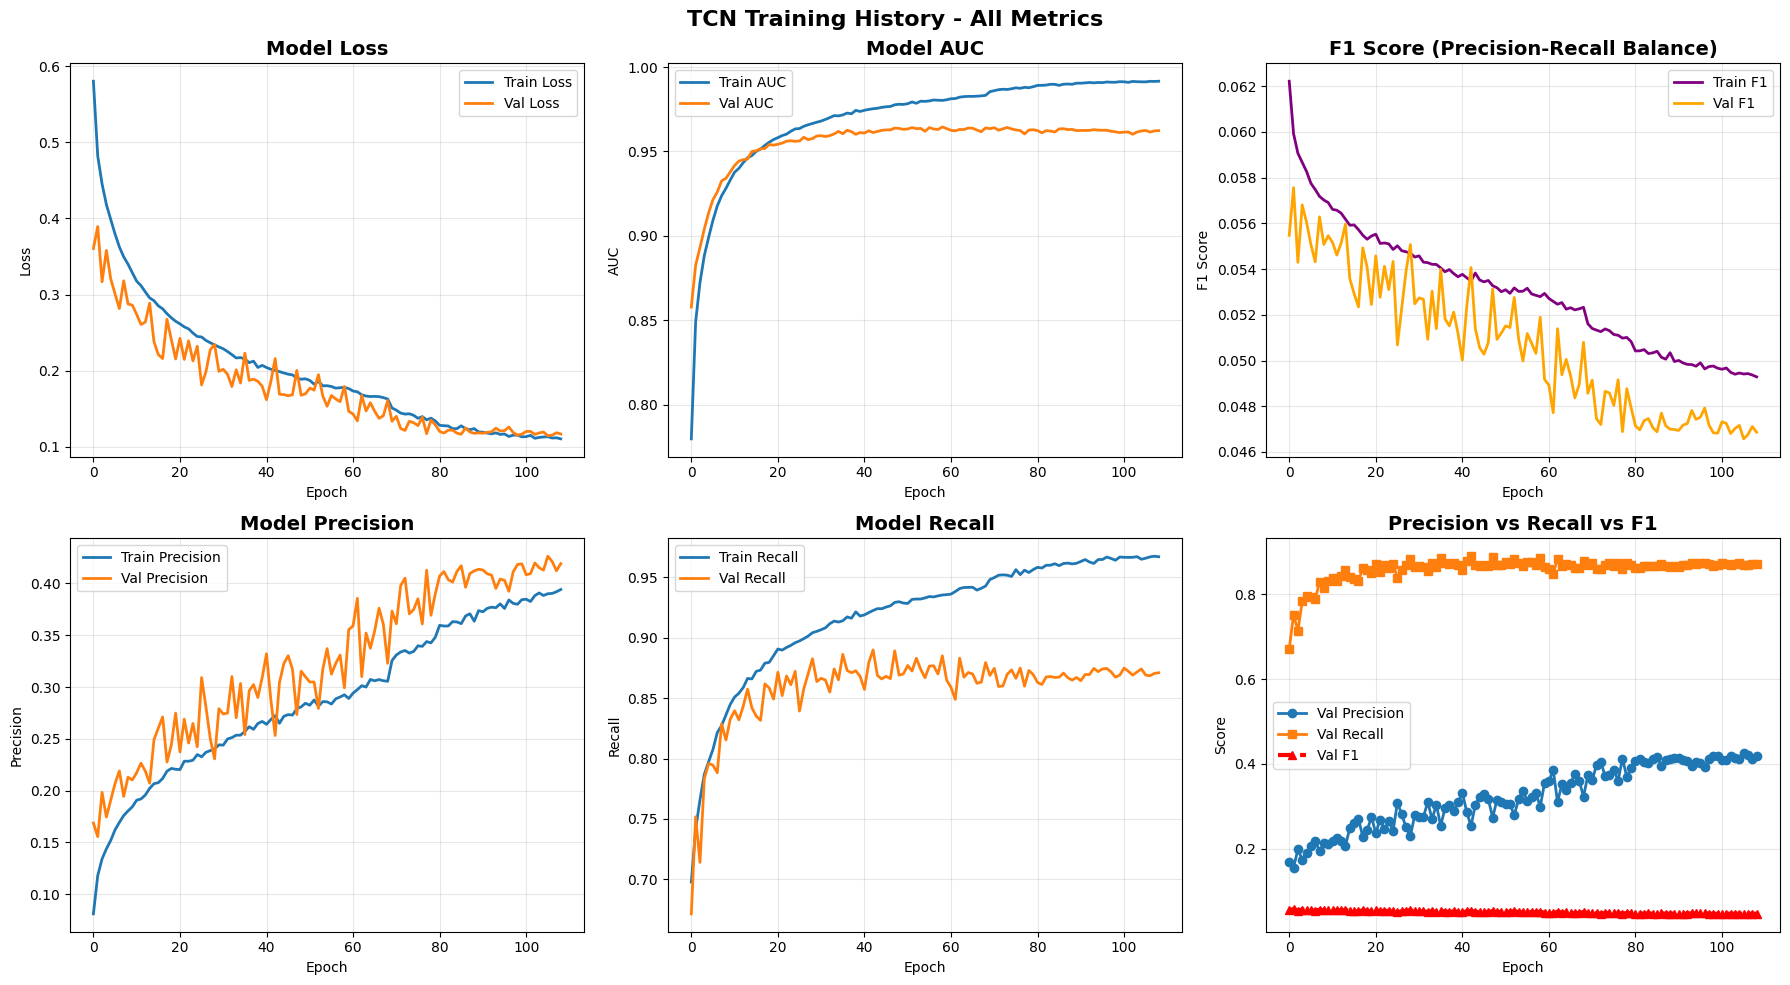

✓ Training history visualized and saved
  Best validation F1 Score: 0.0576


In [25]:
# Plot training history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TCN Training History - All Metrics', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')   
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[0, 1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[0, 1].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
if 'f1_score_metric' in history.history:
    axes[0, 2].plot(history.history['f1_score_metric'], label='Train F1', linewidth=2, color='purple')
    axes[0, 2].plot(history.history['val_f1_score_metric'], label='Val F1', linewidth=2, color='orange')
    axes[0, 2].set_title('F1 Score (Precision-Recall Balance)', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('F1 Score')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
else:
    axes[0, 2].text(0.5, 0.5, 'F1 Score\nNot Available', 
                    ha='center', va='center', fontsize=14)
    axes[0, 2].axis('off')

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Precision vs Recall vs F1 Trade-off
axes[1, 2].plot(history.history['val_precision'], label='Val Precision', linewidth=2, marker='o')
axes[1, 2].plot(history.history['val_recall'], label='Val Recall', linewidth=2, marker='s')
if 'val_f1_score_metric' in history.history:
    axes[1, 2].plot(history.history['val_f1_score_metric'], label='Val F1', 
                    linewidth=3, linestyle='--', color='red', marker='^')
axes[1, 2].set_title('Precision vs Recall vs F1', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'tcn_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training history visualized and saved")
if 'val_f1_score_metric' in history.history:
    print(f"  Best validation F1 Score: {max(history.history['val_f1_score_metric']):.4f}") 

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
TCN MODEL EVALUATION RESULTS
AUC-ROC:   0.9659
Precision: 0.2993
Recall:    0.8851
F1-Score:  0.4474

Confusion Matrix:
  TN: 105,412  |  FP: 8,563
  FN: 475  |  TP: 3,658

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.92      0.96    113975
       Fraud       0.30      0.89      0.45      4133

    accuracy                           0.92    118108
   macro avg       0.65      0.90      0.70    118108
weighted avg       0.97      0.92      0.94    118108



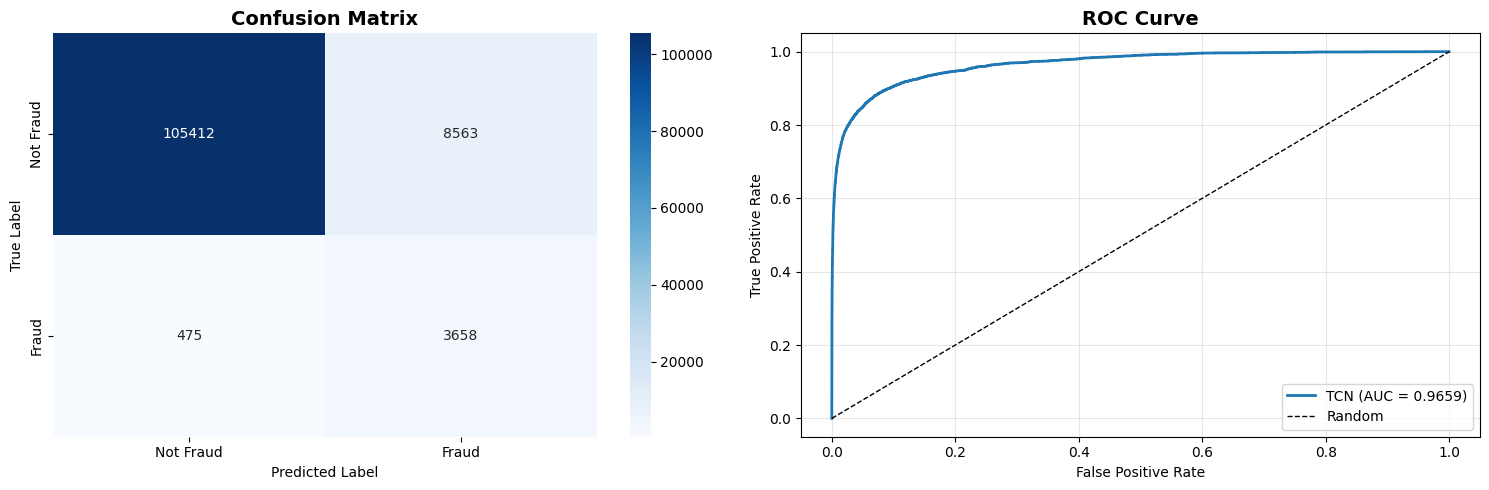


✓ Evaluation completed and visualizations saved


In [26]:
# Make predictions
y_pred_proba = tcn_model.predict(X_val_tcn).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)

auc = roc_auc_score(y_val_tcn, y_pred_proba)
precision = precision_score(y_val_tcn, y_pred)
recall = recall_score(y_val_tcn, y_pred)
f1 = f1_score(y_val_tcn, y_pred)

print("="*60)
print("TCN MODEL EVALUATION RESULTS")
print("="*60)
print(f"AUC-ROC:   {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()

# Confusion Matrix
cm = confusion_matrix(y_val_tcn, y_pred)
print("Confusion Matrix:")
print(f"  TN: {cm[0,0]:,}  |  FP: {cm[0,1]:,}")
print(f"  FN: {cm[1,0]:,}  |  TP: {cm[1,1]:,}")
print()

# Classification Report
print("Classification Report:")
print(classification_report(y_val_tcn, y_pred, target_names=['Not Fraud', 'Fraud']))

# Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val_tcn, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'TCN (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'tcn_evaluation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation completed and visualizations saved")

In [27]:
# Save the final model (already saved by ModelCheckpoint, but save final version too)
final_model_path = os.path.join(MODEL_SAVE_PATH, 'tcn_fraud_final_model.weights.h5')  # ← .weights.h5
tcn_model.save_weights(final_model_path) 
print(f"✓ Final model saved to: {final_model_path}")

# Save the scaler
scaler_path = os.path.join(MODEL_SAVE_PATH, 'tcn_scaler.pkl')
import pickle
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to: {scaler_path}")

# Save evaluation metrics
metrics_dict = {
    'auc': float(auc),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'num_features': features_per_timestep,
    'sequence_length': SEQUENCE_LENGTH,
    'total_params': tcn_model.count_params(),
    'best_val_f1': float(max(history.history.get('val_f1_score_metric', [f1]))) if 'val_f1_score_metric' in history.history else float(f1)
}

metrics_path = os.path.join(RESULTS_PATH, 'tcn_evaluation_metrics.json')
import json
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print(f"✓ Metrics saved to: {metrics_path}")

# Save training history
history_path = os.path.join(RESULTS_PATH, 'tcn_training_history.json')
history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=4)
print(f"✓ Training history saved to: {history_path}")

print("\n" + "="*60)
print("TCN TRAINING PIPELINE COMPLETED!")
print("="*60)
print(f"Model:              {final_model_path}")
print(f"Best model:         {model_checkpoint_path}")
print(f"Scaler:             {scaler_path}")
print(f"Metrics:            {metrics_path}")
print(f"Training history:   {history_path}")
print(f"\nFinal AUC: {auc:.4f}")
print("="*60)

✓ Final model saved to: /kaggle/working/models/tcn_fraud_final_model.weights.h5
✓ Scaler saved to: /kaggle/working/models/tcn_scaler.pkl
✓ Metrics saved to: /kaggle/working/results/tcn_evaluation_metrics.json
✓ Training history saved to: /kaggle/working/results/tcn_training_history.json

TCN TRAINING PIPELINE COMPLETED!
Model:              /kaggle/working/models/tcn_fraud_final_model.weights.h5
Best model:         /kaggle/working/models/tcn_fraud_best_model.weights.h5
Scaler:             /kaggle/working/models/tcn_scaler.pkl
Metrics:            /kaggle/working/results/tcn_evaluation_metrics.json
Training history:   /kaggle/working/results/tcn_training_history.json

Final AUC: 0.9659
